# Trabajo Práctico N°1
## Aprendizaje Automático I
### 2026 
 

**Estudiantes**:

Diez Laureano

Duvia Uriel

Quispe Rocio

## Modelo predictivo de tarifas de Uber


El objetivo de este trabajo es desarrollar un modelo de regresión capaz de predecir la tarifa de un viaje de Uber a partir de variables como la distancia, la cantidad de pasajeros y las coordenadas geográficas de origen y destino. 

Se busca aplicar técnicas de análisis exploratorio de datos, preprocesamiento y modelado utilizando herramientas de aprendizaje automático en Python, con el fin de evaluar el desempeño del modelo y comprender la relación entre las variables involucradas.

## 1- Configuración del entorno

### Se importan las librerías necesarias

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

from sklearn.model_selection import train_test_split
from scipy import stats
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LassoCV, RidgeCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

##  2- Carga e Inspección Estructural del Dataset

#### Sobre el dataset Uber

In [2]:
file_path = 'uber_fares.csv'
df = pd.read_csv(file_path)

El dataset contiene informacion de tarifas de viajes realizados con las siguientes variables:

Características de entrada:


| Variable | Tipo | Descripcion |
|----------|------|-------------|
| `Key` | Entero | Identificador único para cada viaje. |
| `date` | Objeto | Fecha y hora de cada viaje. |
| `pickup_datetime` | Objeto | Fecha y hora en que se activó el taxímetro. |
| `passenger_count` | Entero | Número de pasajeros en el vehículo (valor ingresado por el conductor). |
| `pickup_longitude` | Continua |  Longitud donde se activó el taxímetro. |
| `pickup_latitude` | Continua | Latitud donde se activó el taxímetro. |
| `dropoff_longitude` | Continua | Longitud donde se desactivó el taxímetro. |
| `dropoff_latitude` | Continua | Latitud donde se desactivó el taxímetro. |
| `fare_amount` | Continua |  Costo de cada viaje en USD (target)|



In [3]:
print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Memoria utilizada: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB') 
print()

Dimensiones del dataset: 200000 filas x 9 columnas
Memoria utilizada: 39.20 MB



#### Visualización general del dataset


In [4]:
df.head(10)

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:50:00,8.47,2015-05-07 19:50:00 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:00:04,7.60,2009-07-17 20:00:04 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:49:07,12.65,2009-08-24 21:49:07 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:17:45,5.01,2009-06-26 08:17:45 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:46:18,15.64,2014-08-28 17:46:18 UTC,-73.925023,40.744085,-73.973082,40.761247,5
5,44470845,2011-02-12 02:28:47,4.05,2011-02-12 02:28:47 UTC,-73.969019,40.755910,-73.969019,40.755910,1
6,48725865,2014-10-12 07:01:25,26.73,2014-10-12 07:01:25 UTC,-73.961447,40.693965,-73.871195,40.774297,5
7,44195482,2012-12-11 13:53:11,2.70,2012-12-11 13:53:11 UTC,0.000000,0.000000,0.000000,0.000000,1
8,15822268,2012-02-17 09:34:14,9.50,2012-02-17 09:34:14 UTC,-73.975187,40.745767,-74.002720,40.743537,1
9,50611056,2012-03-29 19:03:22,12.53,2012-03-29 19:03:22 UTC,-74.001065,40.741787,-73.963040,40.775012,1


Se observa que la variable key no es secuencial y las variables date y pickup_datetime tienen los mismos datos aunque en otro formato. 

#### Visualización de los datos

In [5]:
# Inspeccion de tipos de datos y estructura
print('Tipos de datos y valores no nulos:')
print('=' * 46)
df.info()

Tipos de datos y valores no nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  int64  
 1   date               200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


Se observan muy pocos datos nulos


#### Limpieza inicial de datos

En esta etapa se realiza una limpieza inicial del dataset con el objetivo de eliminar variables que no aportan información relevante para el problema.

In [6]:
df = df.drop(columns=["key"])

In [7]:
# Corroboramos si las 2 variables date y pickup_datetime tienen los mismos datos.
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], utc=True)
df['date'] = pd.to_datetime(df['date'], utc=True)

# Verificamos si son iguales
(df['pickup_datetime'] == df['date']).all()

True

In [8]:
# Eliminamos date por ser la columna igual a pickup_datetime
df = df.drop(columns=['date'])

##### Separación de variables

In [9]:
# Separacion de variables por tipo
cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
cols_categoricas = df.select_dtypes(include=['category', 'object']).columns.tolist()

print(f'Variables numericas ({len(cols_numericas)}): {cols_numericas}')
print(f'Variables categoricas ({len(cols_categoricas)}): {cols_categoricas}')

Variables numericas (6): ['fare_amount', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count']
Variables categoricas (0): []


## 3- Análisis descriptivo

In [10]:
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,11.362915,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,9.943248,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,5.970000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,8.430000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,12.660000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,503.130000,57.418457,1644.421482,1153.572603,872.697628,208.000000


Se observa que en passenger_count el valor máximo es de 208, y en fare_amount el máximo de costo es de $508.13. Ambos son extremadamente de muy alto valor.

#### Medidas de Tendencia Central y Descripción

In [11]:
desc = df[cols_numericas].describe().T
desc['mediana'] = df[cols_numericas].median()
desc['CV(%)'] = (desc['std'] / desc['mean']) * 100
desc['sesgo'] = df[cols_numericas].skew()
desc['curtosis'] = df[cols_numericas].kurtosis()

print('Estadisticos descriptivos completos:')
print('=' * 100)
desc[['mean', 'mediana', 'std', 'CV(%)', 'min', '25%', '50%', '75%', 'max',
      'sesgo', 'curtosis']]

Estadisticos descriptivos completos:


,mean,mediana,std,CV(%),min,25%,50%,75%,max,sesgo,curtosis
fare_amount,11.362915,8.430000,9.943248,87.506143,1.000000,5.970000,8.430000,12.660000,503.130000,4.482243,62.246028
pickup_longitude,-72.527638,-73.981823,11.437787,-15.770247,-1340.648410,-73.992065,-73.981823,-73.967154,57.418457,-7.495890,1144.027459
pickup_latitude,39.935885,40.752592,7.720539,19.332336,-74.015515,40.734796,40.752592,40.767158,1644.421482,62.976856,12869.240503
dropoff_longitude,-72.525292,-73.980093,13.117408,-18.086667,-3356.666300,-73.991407,-73.980093,-73.963658,1153.572603,-71.505102,20078.722920
dropoff_latitude,39.923890,40.753042,6.794829,17.019456,-881.985513,40.733823,40.753042,40.768001,872.697628,-8.031012,2981.741917
passenger_count,1.684535,1.000000,1.385997,82.277694,0.000000,1.000000,1.000000,2.000000,208.000000,18.145521,2456.621809


In [12]:
print('Interpretacion del Sesgo y Curtosis:')
print('=' * 60)

for col in cols_numericas:
    sesgo = df[col].skew()
    curtosis = df[col].kurtosis()

    # Clasificacion del sesgo
    if abs(sesgo) < 0.5:
        tipo_sesgo = 'aproximadamente simetrica'
    elif sesgo > 0:
        tipo_sesgo = f'sesgo positivo ({"moderado" if sesgo < 1 else "alto"})'
    else:
        tipo_sesgo = f'sesgo negativo ({"moderado" if abs(sesgo) < 1 else "alto"})'

    # Clasificacion de la curtosis
    if abs(curtosis) < 0.5:
        tipo_curtosis = 'mesocurtica'
    elif curtosis > 0:
        tipo_curtosis = 'leptocurtica (colas pesadas)'
    else:
        tipo_curtosis = 'platicurtica (colas livianas)'

    print(f'  {col:>8s}: sesgo={sesgo:+.3f} [{tipo_sesgo}], '
          f'curtosis={curtosis:+.3f} [{tipo_curtosis}]')

Interpretacion del Sesgo y Curtosis:
  fare_amount: sesgo=+4.482 [sesgo positivo (alto)], curtosis=+62.246 [leptocurtica (colas pesadas)]
  pickup_longitude: sesgo=-7.496 [sesgo negativo (alto)], curtosis=+1144.027 [leptocurtica (colas pesadas)]
  pickup_latitude: sesgo=+62.977 [sesgo positivo (alto)], curtosis=+12869.241 [leptocurtica (colas pesadas)]
  dropoff_longitude: sesgo=-71.505 [sesgo negativo (alto)], curtosis=+20078.723 [leptocurtica (colas pesadas)]
  dropoff_latitude: sesgo=-8.031 [sesgo negativo (alto)], curtosis=+2981.742 [leptocurtica (colas pesadas)]
  passenger_count: sesgo=+18.146 [sesgo positivo (alto)], curtosis=+2456.622 [leptocurtica (colas pesadas)]


#### Análisis estadístico

El análisis descriptivo evidencia la presencia de valores atípicos en múltiples variables del dataset.

La variable fare_amount presenta una fuerte asimetría positiva y alta curtosis, lo que indica la existencia de tarifas extremadamente elevadas. 

Asimismo, las variables geográficas muestran valores fuera de los rangos posibles, lo que evidencia errores en los datos.

Por otro lado, la variable passenger_count contiene valores inválidos, como cero pasajeros o cantidades excesivas.

En conjunto, estos resultados justifican la necesidad de aplicar técnicas de limpieza de datos para mejorar la calidad del dataset antes del modelado.

#### Gráficos de Distribución

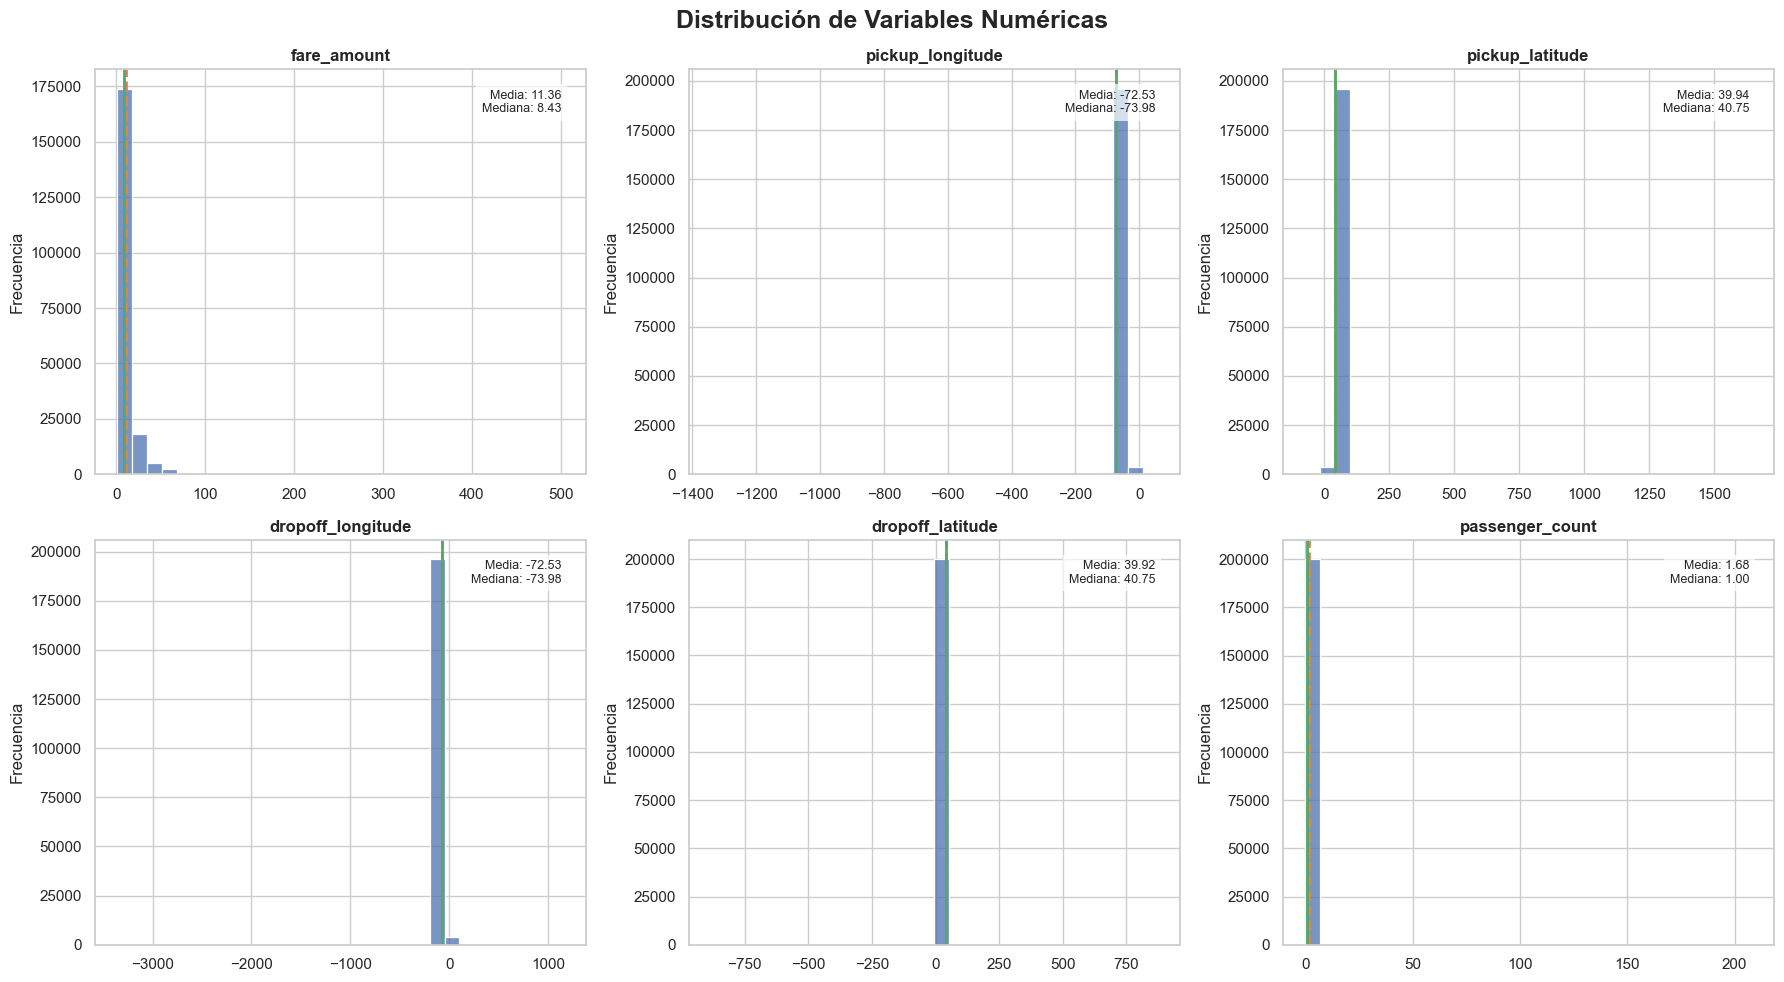

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

# estilo más profesional
sns.set_theme(style="whitegrid")

# columnas numéricas 
cols_numericas = df.select_dtypes(include=np.number).columns

n = len(cols_numericas)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    
    data = df[col].dropna()

    # histograma
    sns.histplot(data, bins=30, kde=False, ax=ax,
                 color='#4C72B0', edgecolor='white')

    # media y mediana
    media = data.mean()
    mediana = data.median()

    ax.axvline(media, color='#DD8452', linestyle='--', linewidth=2)
    ax.axvline(mediana, color='#55A868', linestyle='-', linewidth=2)

    # títulos
    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Frecuencia')

    # texto dentro del gráfico
    ax.text(0.95, 0.95,
            f'Media: {media:.2f}\nMediana: {mediana:.2f}',
            transform=ax.transAxes,
            ha='right', va='top',
            fontsize=9,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# ocultar vacíos
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de Variables Numéricas',
             fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

#### Boxplot

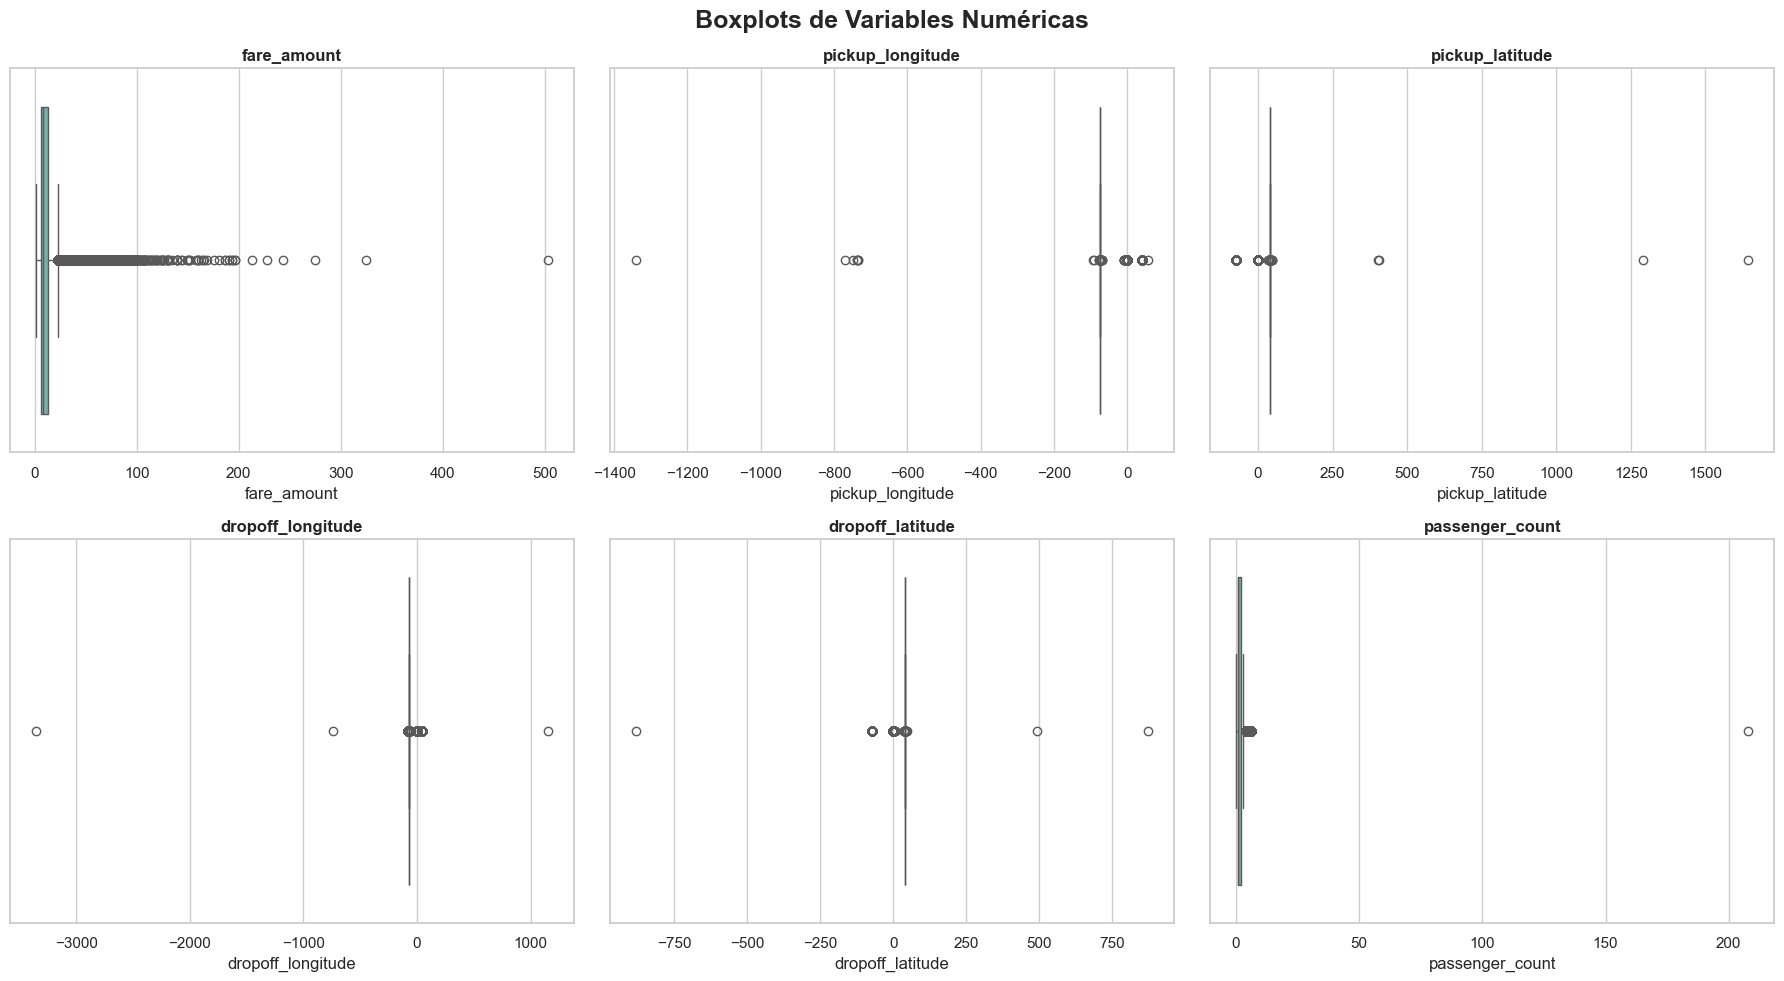

In [14]:
fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]

    sns.boxplot(x=df[col], ax=ax, color='#72B7B2')

    ax.set_title(col, fontsize=12, fontweight='bold')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots de Variables Numéricas',
             fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

<Axes: xlabel='passenger_count', ylabel='count'>

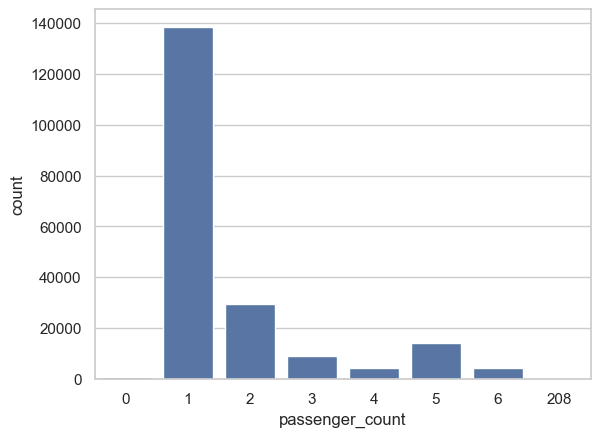

In [15]:
sns.countplot(x=df["passenger_count"])

Se observa que fare_amount tiene outliers, asi como las demás variables.

### 4- Gestión de datos nulos, duplicados y tipos.

Registros nulos.

In [16]:
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df)) * 100

reporte_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': pct_nulos,
    'Tipo': df.dtypes
})

print('Reporte de Valores Nulos:')
print('=' * 50)
print(reporte_nulos)
print(f'\nTotal de celdas con nulos: {nulos.sum()} '
      f'({nulos.sum() / df.size * 100:.4f}% del dataset)')

Reporte de Valores Nulos:
                   Nulos  Porcentaje (%)                 Tipo
fare_amount            0          0.0000              float64
pickup_datetime        0          0.0000  datetime64[ns, UTC]
pickup_longitude       0          0.0000              float64
pickup_latitude        0          0.0000              float64
dropoff_longitude      1          0.0005              float64
dropoff_latitude       1          0.0005              float64
passenger_count        0          0.0000                int64

Total de celdas con nulos: 2 (0.0001% del dataset)


In [41]:
df[df.isna().any(axis=1)]

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
87946,24.15,2013-07-02 03:53:05+00:00,-73.950581,40.779692,NaN,NaN,0


Al ser solo 1 fila con valor faltante, éste  podria ser MCAR.

Registros duplicados

In [17]:
n_duplicados = df.duplicated().sum()
pct_duplicados = n_duplicados / len(df) * 100

print(f'Registros duplicados: {n_duplicados} ({pct_duplicados:.2f}%)')
print()

if n_duplicados > 0:
    print('Ejemplo de registros duplicados:')
    duplicados = df[df.duplicated(keep=False)].sort_values(by=cols_numericas)
    print(duplicados.head(10))
    print()

    # Decision: conservar duplicados (pueden ser diamantes distintos con mismas specs)
    print('DECISION: Se conservan los duplicados.\n'
          'Justificacion: en un dataset de productos fisicos, es plausible que\n'
          'dos diamantes distintos compartan todas sus caracteristicas medidas.\n'
          'Eliminarlos introduciria sesgo por sub-representacion.')

Registros duplicados: 0 (0.00%)



No hay registros duplicados.

#### 5- Pruebas de Normalidad

Test D’Agostino-Pearson

In [18]:
ALPHA = 0.05

resultados_normalidad = []

for col in cols_numericas:
    datos = df[col].dropna()

    # D'Agostino-Pearson (muestra completa)
    stat_dag, p_dag = stats.normaltest(datos)



    resultados_normalidad.append({
        'Variable': col,
        'DAgostino-K2': stat_dag,
        'DAgostino-p': p_dag,
    })

df_normalidad = pd.DataFrame(resultados_normalidad)
print('Resultados de Pruebas de Normalidad:')
print('=' * 80)
df_normalidad

Resultados de Pruebas de Normalidad:


,Variable,DAgostino-K2,DAgostino-p
0,fare_amount,198427.389969,0.0
1,pickup_longitude,295418.248664,0.0
2,pickup_latitude,685429.272943,0.0
3,dropoff_longitude,715878.934499,0.0
4,dropoff_latitude,311371.926750,0.0
5,passenger_count,432578.498101,0.0


Como los resultados del test de D’Agostino-Pearson indican un p-value inferior a 0.05 para todas las variables, entonces se rechaza la hipótesis nula de normalidad. En consecuencia, se concluye que ninguna de las variables analizadas sigue una distribución normal.

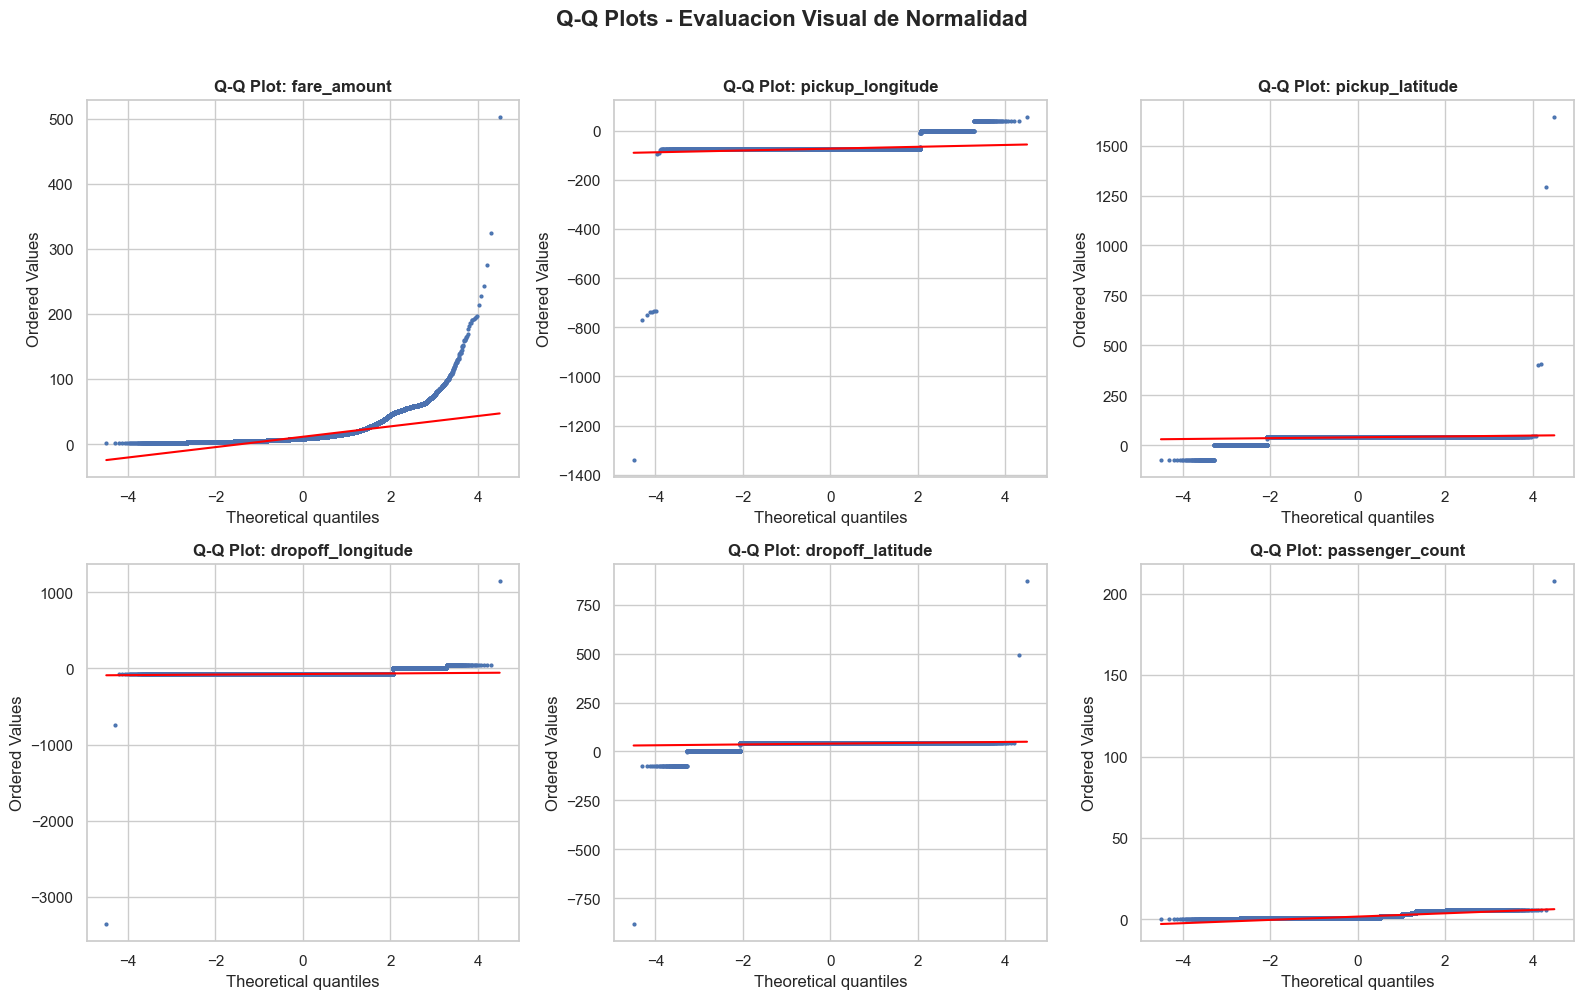

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    datos = df[col].dropna()
    stats.probplot(datos, dist='norm', plot=ax)
    ax.set_title(f'Q-Q Plot: {col}', fontweight='bold')
    ax.get_lines()[0].set_markerfacecolor('steelblue')
    ax.get_lines()[0].set_markersize(2)
    ax.get_lines()[1].set_color('red')

for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Q-Q Plots - Evaluacion Visual de Normalidad',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Los puntos no siguen la línea roja, por lo tanto las variables no son normales. Además hay outliers (en las variables geográficas se muestra alta concentración de datos y presencia de outliers) y sesgo(fare_amount presenta sesgo positivo). La variable passenger_count, al ser discreta, no puede ajustarse a una distribución normal.

### 6- Correlación y Colinealidad

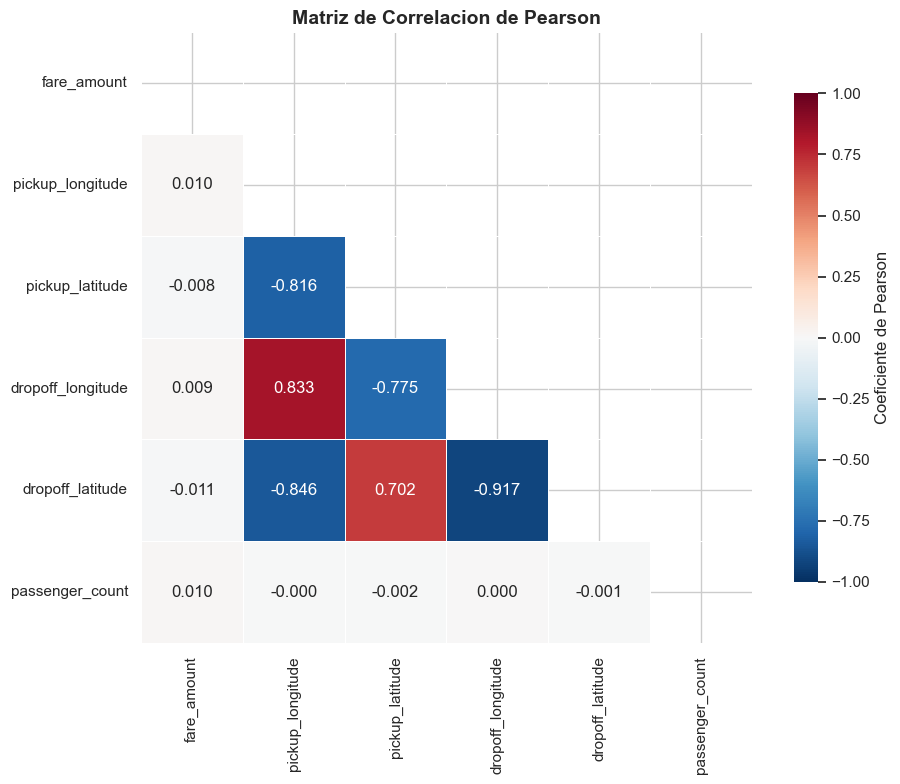

In [20]:
corr_pearson = df[cols_numericas].corr(method='pearson')

# Mascara triangular superior
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_pearson, mask=mask, annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Pearson'})
ax.set_title('Matriz de Correlacion de Pearson', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

La matriz de correlación de Pearson muestra que las variables geográficas individuales (latitud y longitud) presentan correlaciones cercanas a cero con la variable objetivo fare_amount y passenger_count lo que indica la ausencia de relación lineal directa.

Sin embargo, se observan altas correlaciones entre las coordenadas de origen y destino, es esperable dado que los viajes se realizan dentro de una misma área geográfica.

La información relevante no reside en las coordenadas individuales, sino en la distancia entre puntos. Por lo tanto, se propone la creación de una nueva variable que capture dicha distancia, la cual tiene mayor capacidad explicativa sobre la tarifa del viaje.

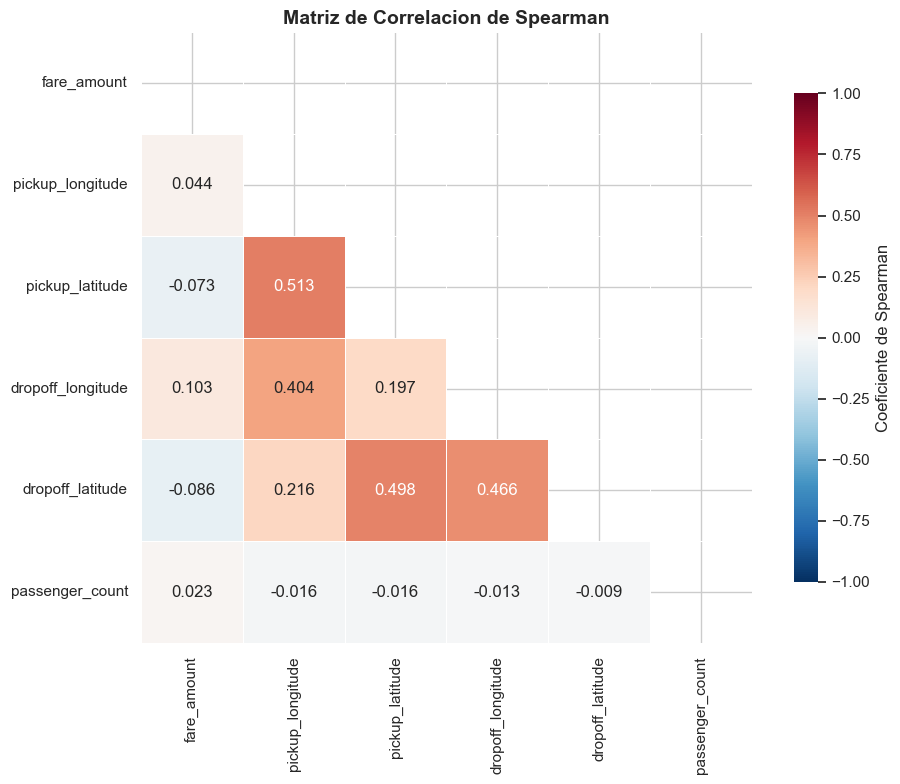

In [21]:
corr_spearman = df[cols_numericas].corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_spearman, mask=mask, annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Spearman'})
ax.set_title('Matriz de Correlacion de Spearman', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Dado que las variables no cumplen el supuesto de normalidad y presentan valores atípicos, la correlación de Spearman resulta más adecuada que Pearson, ya que permite capturar relaciones monótonas no lineales y es más robusta frente a outliers.

Colinealidad

In [22]:
UMBRAL_COLINEALIDAD = 0.85

print(f'Pares con |r_pearson| >= {UMBRAL_COLINEALIDAD} (posible colinealidad):')
print('=' * 60)

pares_colineales = []
for i in range(len(corr_pearson.columns)):
    for j in range(i + 1, len(corr_pearson.columns)):
        r = corr_pearson.iloc[i, j]
        if abs(r) >= UMBRAL_COLINEALIDAD:
            var1 = corr_pearson.columns[i]
            var2 = corr_pearson.columns[j]
            pares_colineales.append((var1, var2, r))
            print(f'  {var1} <-> {var2}: r = {r:.4f}')

if not pares_colineales:
    print('  No se detectaron pares con colinealidad severa.')
else:
    print(f'\nSe detectaron {len(pares_colineales)} par(es) colineal(es).\n'
          f'Considerar eliminar variables redundantes o usar PCA.')

Pares con |r_pearson| >= 0.85 (posible colinealidad):
  dropoff_longitude <-> dropoff_latitude: r = -0.9170

Se detectaron 1 par(es) colineal(es).
Considerar eliminar variables redundantes o usar PCA.


Se detectó colinealidad entre las variables dropoff_longitude y dropoff_latitude, (-0.917), lo cual indica una fuerte dependencia lineal entre ambas.

Esta situación es esperable dado que ambas variables representan coordenadas geográficas dentro de una misma región, por lo que no son independientes.

Sin embargo, eliminar una de ellas implicaría pérdida de información espacial relevante. Por ello, en lugar de eliminar variables, se propone la creación de una nueva variable que capture la distancia entre origen y destino, reduciendo la redundancia y mejorando la capacidad explicativa del modelo.

In [42]:
from sklearn.linear_model import LinearRegression

# Calcular VIF para variables numericas (sin nulos)
df_vif = df[cols_numericas].dropna()

vif_resultados = []
for col in cols_numericas:
    X = df_vif.drop(columns=[col]).values
    y = df_vif[col].values

    reg = LinearRegression().fit(X, y)
    r2 = reg.score(X, y)

    vif = 1 / (1 - r2) if r2 < 1 else np.inf
    vif_resultados.append({'Variable': col, 'R2': r2, 'VIF': vif})

df_vif_result = pd.DataFrame(vif_resultados).sort_values('VIF', ascending=False)

print('Variance Inflation Factor (VIF):')
print('=' * 50)
print('VIF > 10: colinealidad severa | VIF > 5: colinealidad moderada')
print()

for _, row in df_vif_result.iterrows():
    alerta = '  << SEVERA' if row['VIF'] > 10 else ('  << MODERADA' if row['VIF'] > 5 else '')
    print(f"  {row['Variable']:>8s}: VIF = {row['VIF']:>10.2f}{alerta}")

Variance Inflation Factor (VIF):
VIF > 10: colinealidad severa | VIF > 5: colinealidad moderada

  dropoff_longitude: VIF =       7.98  << MODERADA
  dropoff_latitude: VIF =       7.86  << MODERADA
  pickup_longitude: VIF =       5.36  << MODERADA
  pickup_latitude: VIF =       3.54
  fare_amount: VIF =       1.00
  passenger_count: VIF =       1.00


VIF muestra que las coordenadas están correlacionadas entre sí, es lógico porque representan ubicación. Pero no es un error, y conviene transformarlas en una variable Distancia.

### 7- Detección y Tratamiento de Outliers

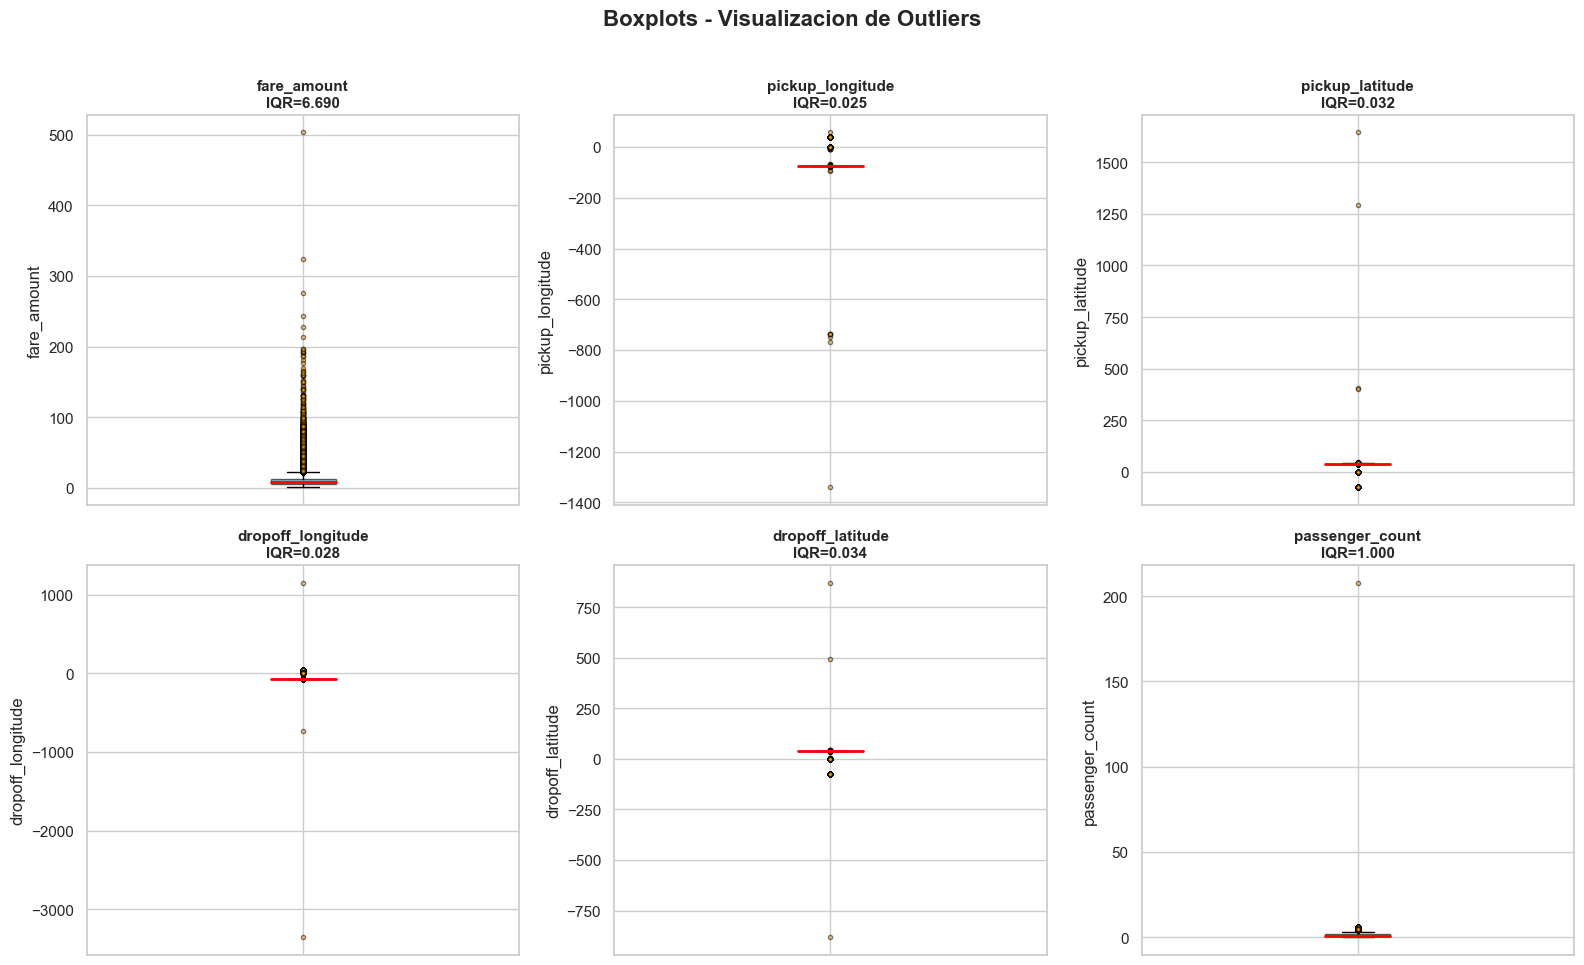

In [43]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    datos = df[col].dropna()

    bp = ax.boxplot(datos, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='orange',
                                    markersize=3, alpha=0.5))

    # Anotaciones de cuartiles
    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1
    ax.set_title(f'{col}\nIQR={iqr:.3f}', fontweight='bold', fontsize=11)
    ax.set_ylabel(col)
    ax.tick_params(axis='x', labelbottom=False)

for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots - Visualizacion de Outliers',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [44]:
Z_THRESHOLD = 3.0
IQR_FACTOR = 1.5

reporte_outliers = []

for col in cols_numericas:
    datos = df[col].dropna()
    n = len(datos)

    # Metodo IQR
    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1
    lim_inf_iqr = q1 - IQR_FACTOR * iqr
    lim_sup_iqr = q3 + IQR_FACTOR * iqr
    outliers_iqr = ((datos < lim_inf_iqr) | (datos > lim_sup_iqr)).sum()

    # Metodo Z-Score
    z_scores = np.abs(stats.zscore(datos))
    outliers_zscore = (z_scores > Z_THRESHOLD).sum()

    reporte_outliers.append({
        'Variable': col,
        'N': n,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'Lim_Inf_IQR': lim_inf_iqr,
        'Lim_Sup_IQR': lim_sup_iqr,
        'Outliers_IQR': outliers_iqr,
        'Pct_IQR(%)': outliers_iqr / n * 100,
        'Outliers_ZScore': outliers_zscore,
        'Pct_ZScore(%)': outliers_zscore / n * 100
    })

df_outliers = pd.DataFrame(reporte_outliers)

print('Reporte de Outliers: Metodo IQR vs Z-Score')
print('=' * 90)
df_outliers[['Variable', 'N', 'IQR', 'Lim_Inf_IQR', 'Lim_Sup_IQR',
             'Outliers_IQR', 'Pct_IQR(%)', 'Outliers_ZScore', 'Pct_ZScore(%)']]

Reporte de Outliers: Metodo IQR vs Z-Score


,Variable,N,IQR,Lim_Inf_IQR,Lim_Sup_IQR,Outliers_IQR,Pct_IQR(%),Outliers_ZScore,Pct_ZScore(%)
0,fare_amount,200000,6.690000,-4.065000,22.695000,16650,8.325000,5432,2.71600
1,pickup_longitude,200000,0.024911,-74.029432,-73.929786,13559,6.779500,3936,1.96800
2,pickup_latitude,200000,0.032362,40.686252,40.815701,9424,4.712000,3907,1.95350
3,dropoff_longitude,199999,0.027749,-74.033030,-73.922036,14200,7.100036,3901,1.95051
4,dropoff_latitude,199999,0.034178,40.682557,40.819268,12145,6.072530,3887,1.94351
5,passenger_count,200000,1.000000,-0.500000,3.500000,22557,11.278500,4272,2.13600


En todos los casos IQR detecta más outliers que Z-score porque no asume normalidad y es más robusto.

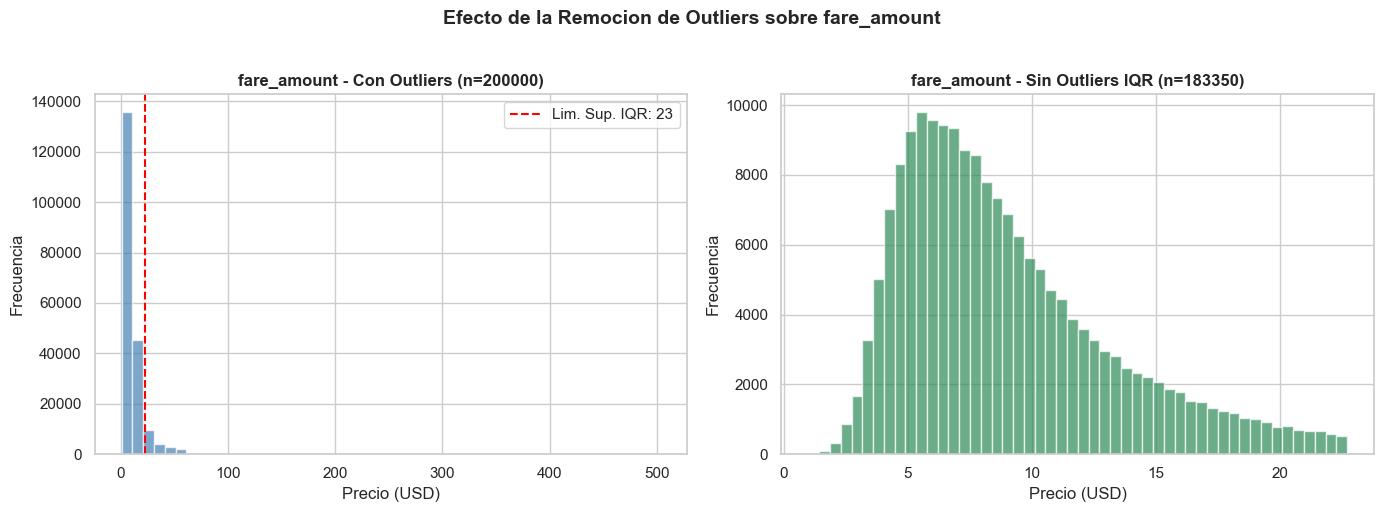

Registros eliminados: 16650 (8.33%)


In [45]:
col_ejemplo = 'fare_amount'
datos = df[col_ejemplo].dropna()

# Limites IQR
q1 = datos.quantile(0.25)
q3 = datos.quantile(0.75)
iqr = q3 - q1
lim_inf = q1 - IQR_FACTOR * iqr
lim_sup = q3 + IQR_FACTOR * iqr

datos_sin_outliers = datos[(datos >= lim_inf) & (datos <= lim_sup)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Con outliers
axes[0].hist(datos, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
axes[0].axvline(lim_sup, color='red', linestyle='--',
                label=f'Lim. Sup. IQR: {lim_sup:.0f}')
axes[0].set_title(f'{col_ejemplo} - Con Outliers (n={len(datos)})',
                  fontweight='bold')
axes[0].set_xlabel('Precio (USD)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Sin outliers
axes[1].hist(datos_sin_outliers, bins=50, color='seagreen',
             edgecolor='white', alpha=0.7)
axes[1].set_title(f'{col_ejemplo} - Sin Outliers IQR (n={len(datos_sin_outliers)})',
                  fontweight='bold')
axes[1].set_xlabel('Precio (USD)')
axes[1].set_ylabel('Frecuencia')

plt.suptitle(f'Efecto de la Remocion de Outliers sobre {col_ejemplo}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Registros eliminados: {len(datos) - len(datos_sin_outliers)} '
      f'({(len(datos) - len(datos_sin_outliers)) / len(datos) * 100:.2f}%)')

### Tratamiento de outliers

Visualizamos las subidas y bajadas en un mapa

In [24]:
info_mapeo = df[['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']]

In [25]:
import geopandas as gpd
import contextily as ctx

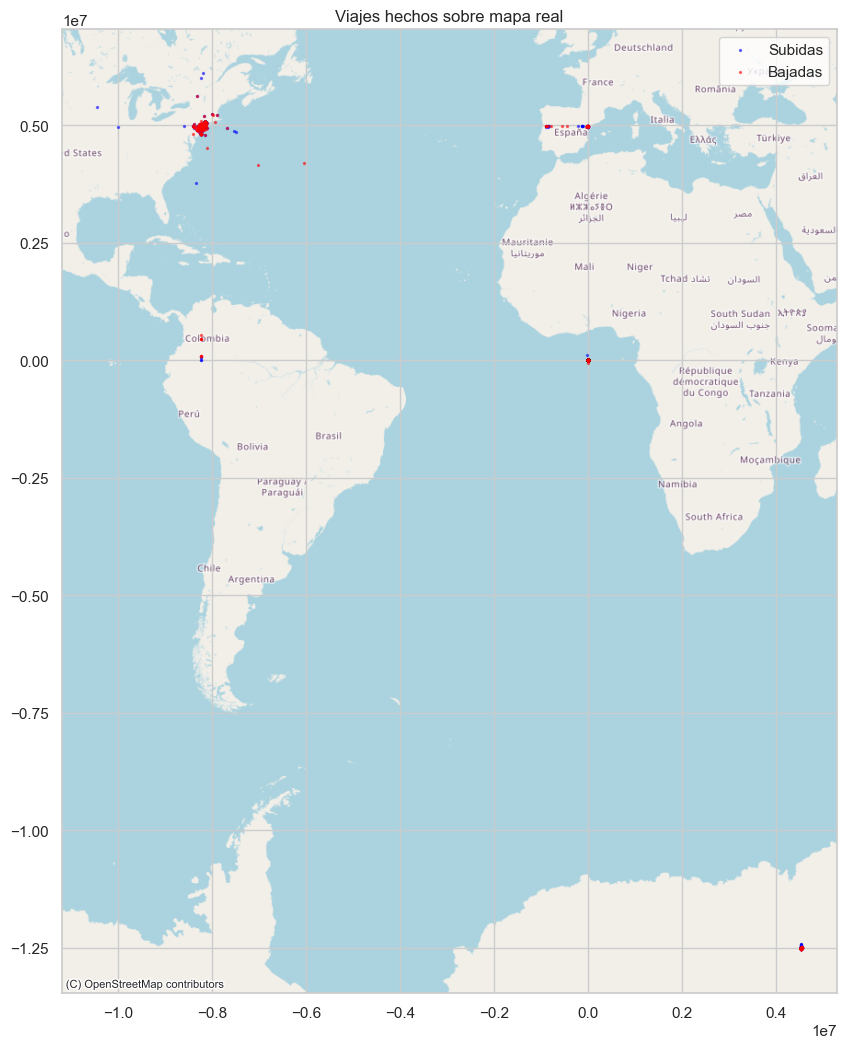

In [26]:
# GeoDataFrame de pickups y dropoffs
gdf_pickup = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(info_mapeo['pickup_longitude'], info_mapeo['pickup_latitude']), crs="EPSG:4326")
gdf_dropoff = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(info_mapeo['dropoff_longitude'], info_mapeo['dropoff_latitude']), crs="EPSG:4326")

# Proyección métrica
gdf_pickup = gdf_pickup.to_crs(epsg=3857)
gdf_dropoff = gdf_dropoff.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 14))
gdf_pickup.plot(ax=ax, markersize=2, color="blue", alpha=0.5, label="Subidas")
gdf_dropoff.plot(ax=ax, markersize=2, color="red", alpha=0.5, label="Bajadas")

# Mapa base
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

plt.legend()
plt.title("Viajes hechos sobre mapa real")
plt.show()

En el mapa observamos que algunos datos estan por fuera de New York. 

In [48]:
# Función para definir las coordenadas de New York
def in_ny(lat, lon):
    return 40 <= lat <= 41 and -75 <= lon <= -72

# Filtro pickups
mask_pickup = df.apply(lambda row: in_ny(row['pickup_latitude'], row['pickup_longitude']), axis=1)

# Filtro dropoffs
mask_dropoff = df.apply(lambda row: in_ny(row['dropoff_latitude'], row['dropoff_longitude']), axis=1)

# Se guardan viajes donde pickup y dropoff están en USA
df_ny = df[mask_pickup & mask_dropoff].copy()

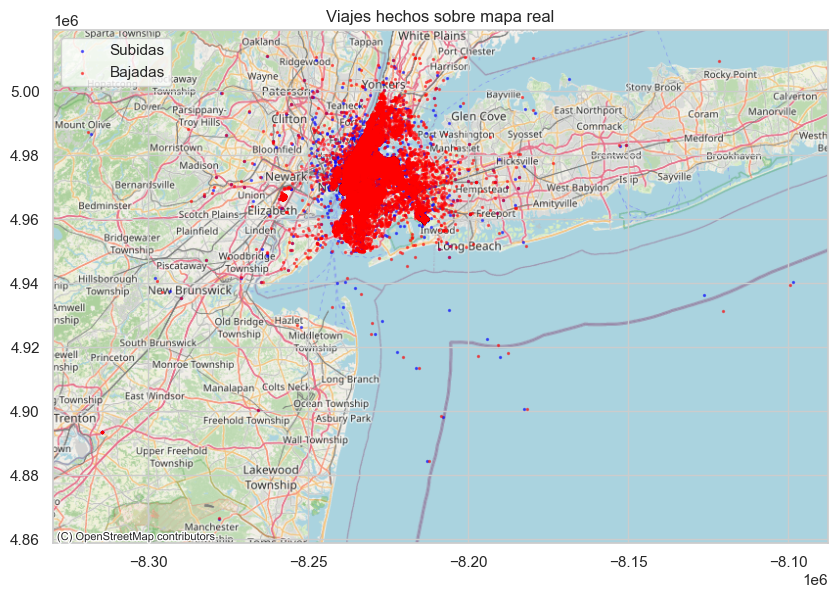

In [49]:
# GeoDataFrame de pickups y dropoffs
gdf_pickup = gpd.GeoDataFrame(df_ny, geometry=gpd.points_from_xy(df_ny['pickup_longitude'], df_ny['pickup_latitude']), crs="EPSG:4326")
gdf_dropoff = gpd.GeoDataFrame(df_ny, geometry=gpd.points_from_xy(df_ny['dropoff_longitude'], df_ny['dropoff_latitude']), crs="EPSG:4326")

# Proyección métrica
gdf_pickup = gdf_pickup.to_crs(epsg=3857)
gdf_dropoff = gdf_dropoff.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 14))
gdf_pickup.plot(ax=ax, markersize=2, color="blue", alpha=0.5, label="Subidas")
gdf_dropoff.plot(ax=ax, markersize=2, color="red", alpha=0.5, label="Bajadas")

# Mapa base
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

plt.legend()
plt.title("Viajes hechos sobre mapa real")
plt.show()


In [29]:
print(f'El dataset original tiene {len(df)} registros. El dataset, tiene {len(df_ny)}. Por lo tanto, se eliminaron {len(df)-len(df_ny)} registros.')

El dataset original tiene 200000 registros. El dataset, tiene 195697. Por lo tanto, se eliminaron 4303 registros.


#### Los datos eliminados representan el 2.15% de los datos. 

Gráficos

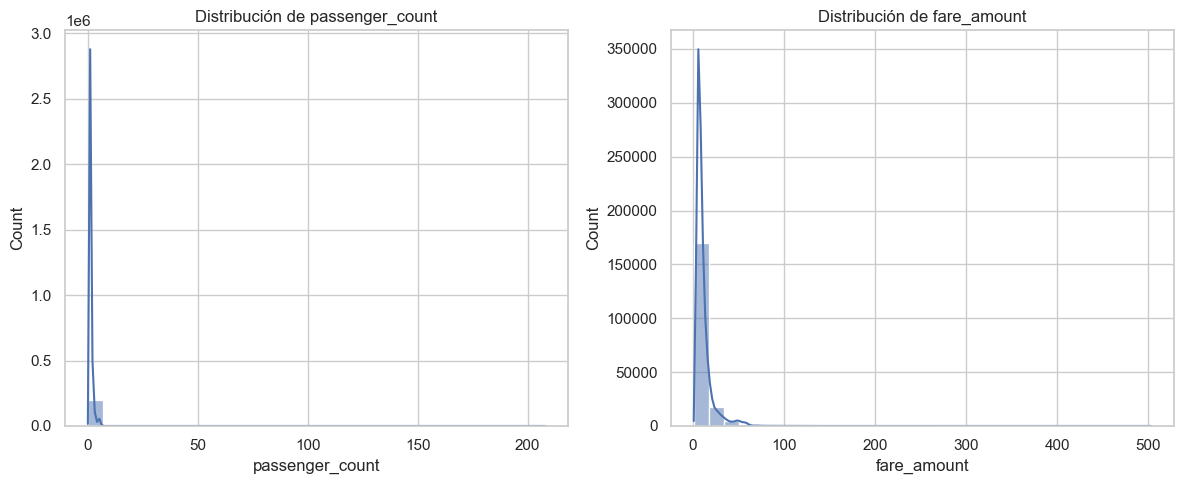

In [31]:
# Gráficos de distribución
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_ny['passenger_count'], bins=30, kde=True)
plt.title('Distribución de passenger_count')

plt.subplot(1, 2, 2)
sns.histplot(df_ny['fare_amount'], bins=30, kde=True)
plt.title('Distribución de fare_amount')

plt.tight_layout()
plt.show()


In [32]:
# Se limpian valores inválidos de fare_amount
Q1 = df_ny['fare_amount'].quantile(0.25)
Q3 = df_ny['fare_amount'].quantile(0.75)
IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR

df_ny.loc[df_ny['fare_amount'] > upper, 'fare_amount'] = np.nan


In [33]:
# Se limpian valores inválidos de passenger_count

df_ny.loc[df_ny['passenger_count'] > 6, 'passenger_count'] = np.nan



In [34]:
# Vemos cuantos nulos hay
df_ny.info()

<class 'pandas.core.frame.DataFrame'>
Index: 195697 entries, 0 to 199999
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   fare_amount        179458 non-null  float64            
 1   pickup_datetime    195697 non-null  datetime64[ns, UTC]
 2   pickup_longitude   195697 non-null  float64            
 3   pickup_latitude    195697 non-null  float64            
 4   dropoff_longitude  195697 non-null  float64            
 5   dropoff_latitude   195697 non-null  float64            
 6   passenger_count    195696 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(6)
memory usage: 11.9 MB


#### Los outliers de passenger_count serán imputados.

In [35]:
df_ny.isnull().sum()

fare_amount          16239
pickup_datetime          0
pickup_longitude         0
pickup_latitude          0
dropoff_longitude        0
dropoff_latitude         0
passenger_count          1
dtype: int64

### 8- Estandarización de variables numéricas

In [ ]:
scaler = StandardScaler()

# Trabajar sobre copia sin nulos
df_num_clean = df[cols_numericas].dropna()
df_estandarizado = pd.DataFrame(
    scaler.fit_transform(df_num_clean),
    columns=cols_numericas,
    index=df_num_clean.index
)

print('Verificacion post-estandarizacion:')
print('=' * 50)
verificacion = pd.DataFrame({
    'Media': df_estandarizado.mean(),
    'Std': df_estandarizado.std(),
    'Min': df_estandarizado.min(),
    'Max': df_estandarizado.max()
})
print(verificacion)
print()
print('Media ~ 0 y Std ~ 1 para todas las variables: estandarizacion correcta.')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes
df_num_clean[['carat', 'depth', 'table', 'price']].plot.box(
    ax=axes[0], patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='red'))
axes[0].set_title('Antes de Estandarizar', fontweight='bold')
axes[0].set_ylabel('Valor original')

# Despues
df_estandarizado[['carat', 'depth', 'table', 'price']].plot.box(
    ax=axes[1], patch_artist=True,
    boxprops=dict(facecolor='seagreen', alpha=0.6),
    medianprops=dict(color='red'))
axes[1].set_title('Despues de Estandarizar (Z-score)', fontweight='bold')
axes[1].set_ylabel('Valor estandarizado')

plt.suptitle('Efecto de la Estandarizacion sobre las Distribuciones',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Conclusiones

### Feature Engineering

### Selección de Features

### Division del dataset en Train y Test

In [36]:
y = df_ny['fare_amount']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(df_ny.drop(columns='fare_amount'), df_ny['fare_amount'], test_size=0.2, random_state=42)

In [38]:
print(f'Tamaño de X_train {X_train.shape}; tamaño de X_test: {X_test.shape}')

Tamaño de X_train (156557, 6); tamaño de X_test: (39140, 6)


#### Imputaciones
Se imputará passenger_count debido a que los outliers detectados los consideramos NaN. Se procede a imputar

In [39]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

features = [
    'pickup_latitude',
    'pickup_longitude',
    'dropoff_latitude',
    'dropoff_longitude'
]

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('imputer', KNNImputer(n_neighbors=5))
])

train = pipeline.fit_transform(X_train[['passenger_count'] + features])
test = pipeline.transform(X_test[['passenger_count'] + features])

### Entrenamiento de Modelos de Regresión Lineal

### Evaluación con métricas